# Bigram Analysis of Trykkefrihedens Skrifter

## Script Summary

This notebook performs bigram (word pair) analysis on *Trykkefrihedens Skrifter* in Python, inspired by the R workflow. Bigram analysis identifies frequently co-occurring word pairs to reveal linguistic patterns and phrase structures in historical Danish texts.

**Steps:**
- Load the structured dataset and project-specific stopwords
- Create bigrams (word pairs) for each text in the dataset
- Count the frequency of each bigram across the corpus
- Filter out bigrams containing stopwords to focus on meaningful word combinations
- Search for specific bigrams matching patterns (e.g., words starting with 'gud')
- Visualize frequent bigrams as network graphs showing word relationships
- Export results to CSV files and save network visualizations

**Outputs:** Bigram frequency tables, filtered bigram results, pattern-matched bigrams, network graph visualizations, and CSV files for further analysis.

---

## Install and Import Dependencies

If you're missing any packages, uncomment and run the pip cell below.

In [1]:
# !pip install pandas numpy nltk matplotlib seaborn networkx

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lakj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lakj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Data

**Check your data files:**
You need the main text data and project-specific stopwords as csv files.

   - `tfs_structured.csv` — Main text data
   - `tfs_stopord.csv` — Project-specific stopwords

You can find them in the corresponding repository: https://github.com/kb-dk/cultural-heritage-data-guides-Python

Or you can load them through these links:
- https://raw.githubusercontent.com/maxodsbjerg/TextMiningTFS/refs/heads/main/data/tfs_structured.csv 
- https://raw.githubusercontent.com/maxodsbjerg/TextMiningTFS/refs/heads/main/data/tfs_stopord.csv


Here we load the .csv files from our project folder.

The **Data Structure** in `tfs_structured.csv` is:

- `refnr`: Reference number
- `række`: Series number
- `bind`: Volume number
- `side`: Page number
- `content`: Text content



With the data in the right folder we load the main data and stopwords from CSV files.

In [2]:
main_data_path = 'tfs_structured.csv'
stopwords_path = 'tfs_stopord.csv'

try:
    tfs = pd.read_csv(main_data_path)
    print(f'Data loaded. Shape: {tfs.shape}')
except FileNotFoundError:
    print(f'File not found: {main_data_path}')
    tfs = None

try:
    stopord_tfs = pd.read_csv(stopwords_path)['word'].astype(str).str.lower().tolist()
    print(f'Loaded {len(stopord_tfs)} project-specific stopwords.')
except Exception as e:
    print(f'Could not load project-specific stopwords: {e}')
    stopord_tfs = []

# Optional extra stopwords list from URL (can be added if desired)
# stopord_url = "https://gist.githubusercontent.com/maxodsbjerg/4d1e3b1081ebba53a8d2c3aae2a1a070/raw/e1f63b4c81c15bb58a54a2f94673c97d75fe6a74/stopord_18.csv"
# stopord_extra = pd.read_csv(stopord_url)['word'].astype(str).str.lower().tolist()
# stopord_tfs += stopord_extra

Data loaded. Shape: (28133, 14)
Loaded 60 project-specific stopwords.


## Formation of Bigrams

We create bigrams (word pairs) for each text.

In [3]:
def regex_tokenize(text):
    # Simple tokenization, can be extended if needed
    return re.findall(r'\b\S+\b', str(text).lower())

def make_bigrams(tokens):
    return [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]

# Create bigrams for all rows
if tfs is not None:
    bigrams_list = []
    for idx, row in tfs.iterrows():
        tokens = regex_tokenize(row['content'])
        bigrams = make_bigrams(tokens)
        for bg in bigrams:
            bigrams_list.append({'refnr': row.get('refnr', idx),
                                 'række': row.get('række', None),
                                 'bind': row.get('bind', None),
                                 'side': row.get('side', None),
                                 'word1': bg[0],
                                 'word2': bg[1]})

    tfs_bigrams = pd.DataFrame(bigrams_list)
    print(f'Number of bigrams: {len(tfs_bigrams)}')
    display(tfs_bigrams.head())
else:
    print('Data not loaded. Please ensure tfs_structured.csv is available.')
    tfs_bigrams = pd.DataFrame()

Number of bigrams: 4402472


,refnr,række,bind,side,word1,word2
0,1.1.1,1,1,1,philopatreias,trende
1,1.1.1,1,1,1,trende,anmærkninger
2,1.1.1,1,1,1,anmærkninger,i
3,1.1.1,1,1,1,i,om
4,1.1.1,1,1,1,om,de


## Count Bigrams

We count the frequency of each bigram (word pair).

In [4]:
bigram_counts = tfs_bigrams.groupby(['word1', 'word2']).size().reset_index(name='count')
bigram_counts = bigram_counts.sort_values('count', ascending=False)
display(bigram_counts.head(20))

,word1,word2,count
1417738,til,at,10099
335398,det,er,6434
507506,for,at,6155
130779,at,de,5393
444015,er,det,3924
132588,at,han,3605
759583,i,det,3584
759543,i,den,3010
759924,i,en,3003
130867,at,det,2853


## Remove Bigrams Where One of the Words is a Stopword

We remove bigrams where either word1 or word2 is a stopword (Danish, German, or project-specific).

In [5]:
stopord_da = set(stopwords.words('danish'))
stopord_de = set(stopwords.words('german'))
stopord_all = stopord_da | stopord_de | set(stopord_tfs)

bigrams_filtered = tfs_bigrams[
    (~tfs_bigrams['word1'].isin(stopord_all)) &
    (~tfs_bigrams['word2'].isin(stopord_all))
]
print(f'Number of bigrams after stopword filtering: {len(bigrams_filtered)}')

Number of bigrams after stopword filtering: 966952


## Count Filtered Bigrams

We now count bigrams without stopwords.

In [6]:
bigram_counts_filtered = bigrams_filtered.groupby(['word1', 'word2']).size().reset_index(name='count')
bigram_counts_filtered = bigram_counts_filtered.sort_values('count', ascending=False)
display(bigram_counts_filtered.head(20))

,word1,word2,count
358413,kiøbenhavn,1771,477
552523,skilling,stor,353
9418,1771,trykt,318
560772,slet,intet,305
358686,kiøbenhavn,trykt,275
9615,1772,trykt,272
524686,s,v,266
461193,o,s,266
340844,intet,andet,262
381451,lang,tid,251


## Search for Specific Bigrams (e.g., where word2 matches a pattern)

We can filter bigrams where word2 matches a specific pattern, e.g., words starting with 'gud'.

In [7]:
pattern = r'\bgud[a-zæø]*'
match_bigrams = bigrams_filtered[bigrams_filtered['word2'].str.contains(pattern, regex=True)]
match_counts = match_bigrams.groupby(['word1', 'word2']).size().reset_index(name='count')
match_counts = match_counts.sort_values('count', ascending=False)
display(match_counts.head(20))

,word1,word2,count
1523,o,gud,95
1145,imod,gud,83
1935,store,gud,47
2011,takke,gud,38
816,frygte,gud,35
993,herre,gud,32
1195,jordens,guder,31
1148,imod,guds,31
913,gode,gud,29
1791,sande,gud,28


## Visualization as Network Graph

We can visualize the most frequent bigrams as a network graph.

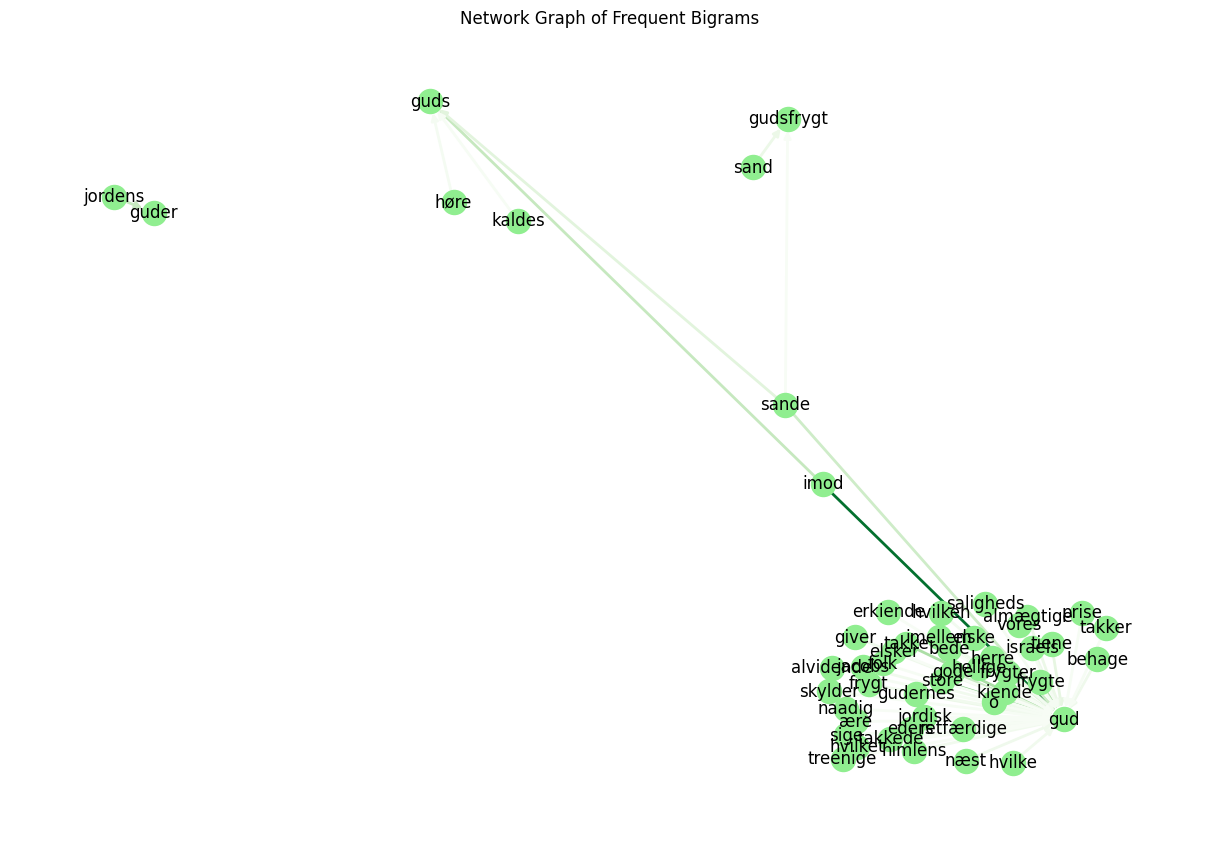

In [8]:
# Select bigrams that occur more than e.g., 8 times
threshold = 8
graph_data = match_counts[match_counts['count'] > threshold]

G = nx.DiGraph()
for _, row in graph_data.iterrows():
    G.add_edge(row['word1'], row['word2'], weight=row['count'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
nx.draw(G, pos, with_labels=True, node_color='lightgreen', edge_color=weights, width=2.0, edge_cmap=plt.cm.Greens, arrows=True)
plt.title('Network Graph of Frequent Bigrams')
plt.show()

## Save Graph and Results

You can save the graph and results as CSV files.

In [9]:
bigram_counts_filtered.to_csv('results_bigrams_filtered.csv', index=False)
match_counts.to_csv('results_bigrams_match.csv', index=False)
plt.savefig('graphics/bigram_network.png', bbox_inches='tight', dpi=150)
print('Results and graph saved.')

Results and graph saved.


<Figure size 640x480 with 0 Axes>

## Other studies

The bigram analysis of Trykkefrihedens Skrifter can be extended with several complementary approaches:

- Expand pattern matching to explore other semantic domains (e.g., political terms, social concepts, religious language) and identify distinctive phrase patterns.
- Analyze temporal changes in bigram usage by comparing frequent word pairs across different publication periods.
- Investigate trigram and n-gram patterns to explore longer phrase structures and multi-word expressions.
- Apply network analysis techniques to identify central nodes and communities in the bigram network.
- Compare bigram patterns with other historical Danish text collections to identify genre-specific or period-specific linguistic features.
- Explore the relationship between bigram frequency and semantic coherence to identify meaningful versus coincidental co-occurrences.
- Analyze bigram patterns in specific volumes or series to identify thematic or stylistic variations.
- Integrate bigram analysis with topic modeling to understand how word pairs contribute to broader thematic structures.
